# Taller 05 · Modelos de Clasificación — Predicción de Envíos en E-Commerce

**Caso de negocio.** Una empresa internacional de e-commerce que vende productos electrónicos
quiere anticipar **qué envíos llegarán tarde** para actuar antes de incumplir con el cliente
(reprogramar transporte, priorizar despachos, avisar proactivamente).

**Tarea.** Problema de **clasificación binaria**: predecir la columna `Reached.on.Time_Y.N`
donde **1 = NO llegó a tiempo (tarde)** y **0 = llegó a tiempo**.

**Plan de trabajo**
1. Carga de datos y análisis exploratorio (EDA).
2. Preprocesamiento: encoding ordinal + One-Hot de variables categóricas.
3. División train / test.
4. Entrenamiento de **tres** clasificadores: Regresión Logística, Árbol de Decisión y Random Forest.
5. Evaluación y comparación (Accuracy, matrices de confusión, reporte de clasificación) y elección del mejor modelo.


In [1]:
# Paso 0: Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos de clasificación de scikit-learn (los tres que vamos a comparar)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Utilidades de preprocesamiento, partición y métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

# Configuración estética y reproducibilidad
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


## 1. Carga de Datos y Análisis Exploratorio Inicial

Los datos provienen de [E-Commerce Shipping Data](https://www.kaggle.com/datasets/prachi13/customer-analytics).
El archivo `Train.csv` debe estar en la misma carpeta que este notebook.

In [2]:
# Paso 1: Cargar el dataset con pandas
df = pd.read_csv("Train.csv")

print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.\n")
df.head()


El dataset tiene 10999 filas y 12 columnas.



,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
# Tipos de datos y valores nulos
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.0 MB


In [4]:
# ¿Hay valores nulos o filas duplicadas?
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas duplicadas: {df.duplicated().sum()}")


Valores nulos por columna:
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

Filas duplicadas: 0


In [5]:
# Estadísticos descriptivos de las variables numéricas
df.describe()


,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


### EDA visual

Antes de modelar conviene entender el **balance del target** y cómo se relacionan
algunas variables clave con la puntualidad del envío.

/tmp/ipykernel_1027/4036233789.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, ax=axes[0], palette="Set2", order=orden)


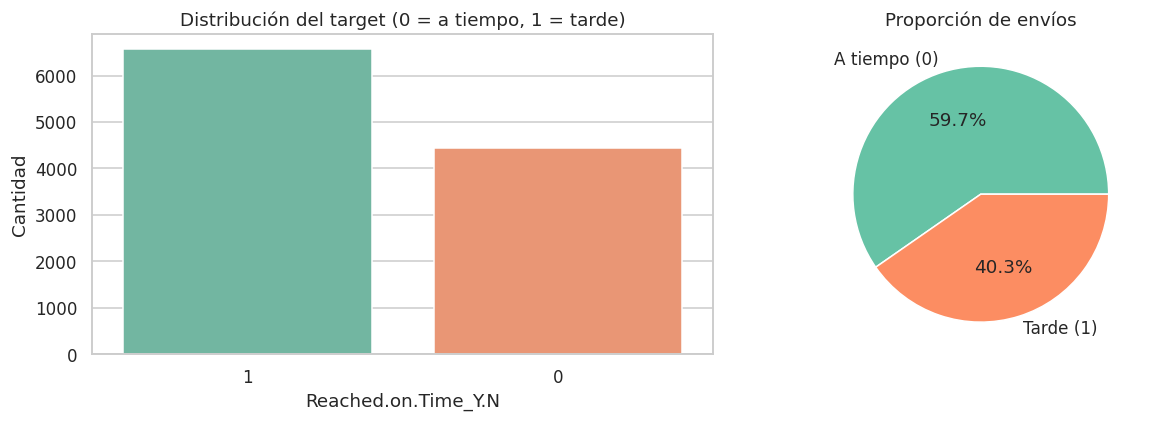

El dataset está razonablemente balanceado (~60% tarde / ~40% a tiempo),
por lo que Accuracy es una métrica válida, aunque la complementaremos con la matriz de confusión.


In [6]:
# Distribución de la variable objetivo
target_col = "Reached.on.Time_Y.N"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

orden = df[target_col].value_counts().index
sns.countplot(x=target_col, data=df, ax=axes[0], palette="Set2", order=orden)
axes[0].set_title("Distribución del target (0 = a tiempo, 1 = tarde)")
axes[0].set_xlabel("Reached.on.Time_Y.N")
axes[0].set_ylabel("Cantidad")

df[target_col].value_counts(normalize=True).plot.pie(
    autopct="%1.1f%%", ax=axes[1], colors=["#66c2a5", "#fc8d62"],
    labels=["A tiempo (0)", "Tarde (1)"], ylabel="")
axes[1].set_title("Proporción de envíos")

plt.tight_layout()
plt.show()

print("El dataset está razonablemente balanceado (~60% tarde / ~40% a tiempo),")
print("por lo que Accuracy es una métrica válida, aunque la complementaremos con la matriz de confusión.")


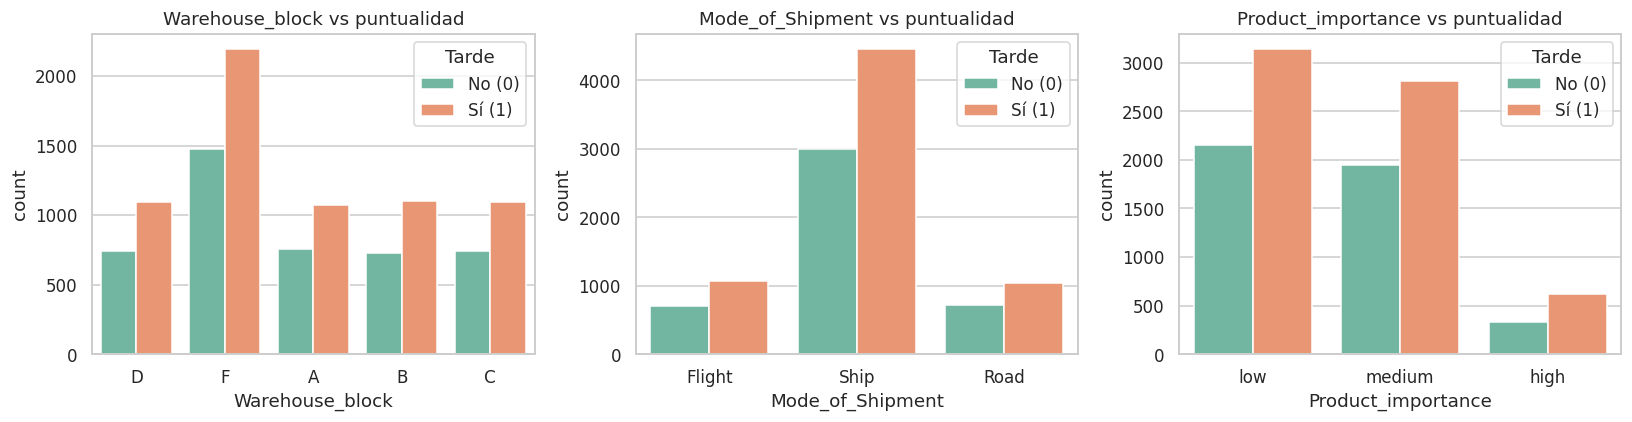

In [7]:
# Relación de variables categóricas con la puntualidad
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Warehouse_block", "Mode_of_Shipment", "Product_importance"]):
    sns.countplot(x=col, hue=target_col, data=df, ax=ax, palette="Set2")
    ax.set_title(f"{col} vs puntualidad")
    ax.legend(title="Tarde", labels=["No (0)", "Sí (1)"])
plt.tight_layout()
plt.show()


/tmp/ipykernel_1027/3042873578.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y="Discount_offered", data=df, palette="Set2")


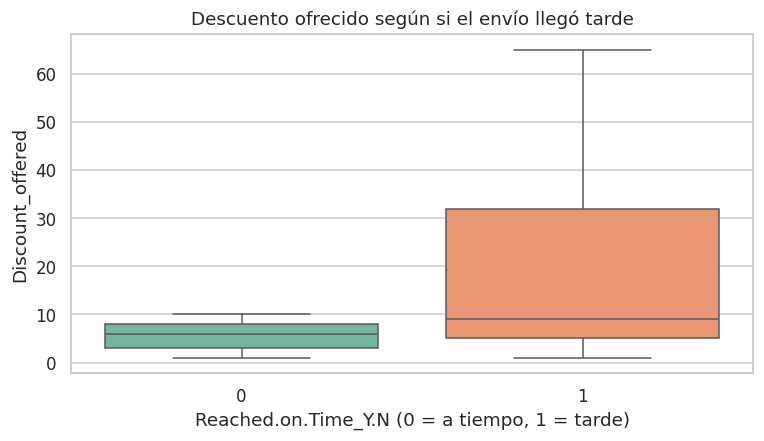

Observación: los envíos con descuentos altos tienden a llegar tarde con mucha más frecuencia.


In [8]:
# El descuento ofrecido suele ser muy informativo en este dataset
plt.figure(figsize=(8, 4))
sns.boxplot(x=target_col, y="Discount_offered", data=df, palette="Set2")
plt.title("Descuento ofrecido según si el envío llegó tarde")
plt.xlabel("Reached.on.Time_Y.N (0 = a tiempo, 1 = tarde)")
plt.show()

print("Observación: los envíos con descuentos altos tienden a llegar tarde con mucha más frecuencia.")


## 2. Preprocesamiento de Datos e Ingeniería de Características

Transformamos las variables categóricas a formato numérico siguiendo dos estrategias:

- **Encoding ordinal** para `Product_importance`, que tiene un orden lógico (`low < medium < high`).
- **One-Hot Encoding** para `Warehouse_block` y `Mode_of_Shipment`, que **no** tienen orden.
  También codificamos `Gender`.

Además eliminamos `ID`, que es solo un identificador sin valor predictivo.

In [9]:
# Paso 2: Identificación y transformación de variables categóricas
df_proc = df.copy()

# Eliminamos el identificador (no aporta información predictiva)
df_proc = df_proc.drop(columns=["ID"])

# --- Encoding ORDINAL: Product_importance tiene jerarquía lógica ---
orden_importancia = {"low": 1, "medium": 2, "high": 3}
df_proc["Product_importance"] = df_proc["Product_importance"].map(orden_importancia)

# --- One-Hot Encoding: variables sin orden lógico ---
# drop_first=True evita la multicolinealidad (trampa de variables dummy)
df_proc = pd.get_dummies(
    df_proc,
    columns=["Warehouse_block", "Mode_of_Shipment", "Gender"],
    drop_first=True
)

# Convertimos los booleanos de get_dummies a enteros (0/1) por claridad
bool_cols = df_proc.select_dtypes(include="bool").columns
df_proc[bool_cols] = df_proc[bool_cols].astype(int)

print("Columnas tras el preprocesamiento:")
print(list(df_proc.columns))
df_proc.head()


Columnas tras el preprocesamiento:
['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N', 'Warehouse_block_B', 'Warehouse_block_C', 'Warehouse_block_D', 'Warehouse_block_F', 'Mode_of_Shipment_Road', 'Mode_of_Shipment_Ship', 'Gender_M']


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Gender_M
0,4,2,177,3,1,44,1233,1,0,0,1,0,0,0,0
1,4,5,216,2,1,59,3088,1,0,0,0,1,0,0,1
2,2,2,183,4,1,48,3374,1,0,0,0,0,0,0,1
3,3,3,176,4,2,10,1177,1,1,0,0,0,0,0,1
4,2,2,184,3,2,46,2484,1,0,1,0,0,0,0,0


In [10]:
# Paso 2b: Definición de la matriz de características (X) y el vector objetivo (y)
X = df_proc.drop(columns=[target_col])
y = df_proc[target_col]

print(f"X -> {X.shape[0]} filas y {X.shape[1]} características")
print(f"y -> {y.shape[0]} etiquetas")


X -> 10999 filas y 14 características
y -> 10999 etiquetas


## 3. División del Dataset

Separamos en entrenamiento (80%) y prueba (20%). Usamos `stratify=y` para
conservar la proporción del target en ambos conjuntos y `random_state` fijo
para que los resultados sean replicables.

In [11]:
# Paso 3: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba:        {X_test.shape[0]} filas")

# La Regresión Logística es sensible a la escala de las variables, así que
# estandarizamos. Ajustamos (fit) SOLO con train para no filtrar información del test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nVariables escaladas para los modelos que lo requieren (Regresión Logística).")


Entrenamiento: 8799 filas
Prueba:        2200 filas

Variables escaladas para los modelos que lo requieren (Regresión Logística).


## 4. Entrenamiento de Modelos

Entrenamos **tres** algoritmos de clasificación distintos:

| Modelo | ¿Por qué se incluye? | ¿Usa datos escalados? |
|--------|----------------------|------------------------|
| Regresión Logística | Modelo lineal, base de referencia interpretable | Sí |
| Árbol de Decisión | Captura relaciones no lineales; muy interpretable | No (es invariante a la escala) |
| Random Forest | Conjunto de árboles, suele dar el mejor desempeño | No |


In [12]:
## Paso 4: Entrenamiento y evaluación de los tres modelos

# Guardaremos predicciones y modelos en diccionarios para comparar después
modelos = {}
predicciones = {}

# --- Modelo 1: Regresión Logística (con datos escalados) ---
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
predicciones["Regresión Logística"] = log_reg.predict(X_test_scaled)
modelos["Regresión Logística"] = log_reg

# --- Modelo 2: Árbol de Decisión (datos sin escalar) ---
arbol = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)
arbol.fit(X_train, y_train)
predicciones["Árbol de Decisión"] = arbol.predict(X_test)
modelos["Árbol de Decisión"] = arbol

# --- Modelo 3: Random Forest (datos sin escalar) ---
bosque = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
bosque.fit(X_train, y_train)
predicciones["Random Forest"] = bosque.predict(X_test)
modelos["Random Forest"] = bosque

print("Los tres modelos fueron entrenados y ya generaron predicciones sobre el conjunto de prueba.")


Los tres modelos fueron entrenados y ya generaron predicciones sobre el conjunto de prueba.


## 5. Evaluación y Comparación de Resultados

Calculamos las métricas para los tres modelos y las comparamos con gráficas.

In [13]:
# Paso 5: Cálculo de métricas para cada modelo
resultados = []
for nombre, y_pred in predicciones.items():
    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
    })

tabla = pd.DataFrame(resultados).sort_values("Accuracy", ascending=False).reset_index(drop=True)
tabla.style.format({c: "{:.3f}" for c in ["Accuracy", "Precision", "Recall", "F1-score"]})


,Modelo,Accuracy,Precision,Recall,F1-score
0,Árbol de Decisión,0.685,0.900,0.530,0.667
1,Random Forest,0.655,0.758,0.621,0.683
2,Regresión Logística,0.640,0.709,0.674,0.691


In [14]:
# Reporte de clasificación detallado de cada modelo
for nombre, y_pred in predicciones.items():
    print("=" * 60)
    print(f"  {nombre}")
    print("=" * 60)
    print(classification_report(y_test, y_pred, target_names=["A tiempo (0)", "Tarde (1)"]))


  Regresión Logística
              precision    recall  f1-score   support

A tiempo (0)       0.55      0.59      0.57       887
   Tarde (1)       0.71      0.67      0.69      1313

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.64      0.64      0.64      2200

  Árbol de Decisión
              precision    recall  f1-score   support

A tiempo (0)       0.57      0.91      0.70       887
   Tarde (1)       0.90      0.53      0.67      1313

    accuracy                           0.68      2200
   macro avg       0.73      0.72      0.68      2200
weighted avg       0.77      0.68      0.68      2200

  Random Forest
              precision    recall  f1-score   support

A tiempo (0)       0.56      0.71      0.62       887
   Tarde (1)       0.76      0.62      0.68      1313

    accuracy                           0.66      2200
   macro avg       0.66      0.66      0.65      2200
weighted avg    

/tmp/ipykernel_1027/3553669396.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Modelo", y="Accuracy", data=tabla, palette="viridis")


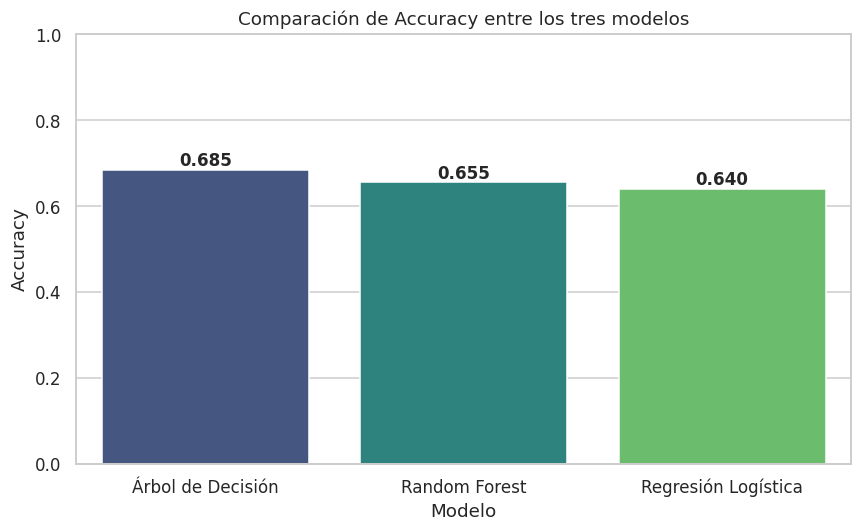

In [15]:
# Paso 6: Gráfica comparativa de Accuracy
plt.figure(figsize=(8, 5))
ax = sns.barplot(x="Modelo", y="Accuracy", data=tabla, palette="viridis")
plt.title("Comparación de Accuracy entre los tres modelos")
plt.ylim(0, 1)
plt.ylabel("Accuracy")

# Etiqueta numérica encima de cada barra
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


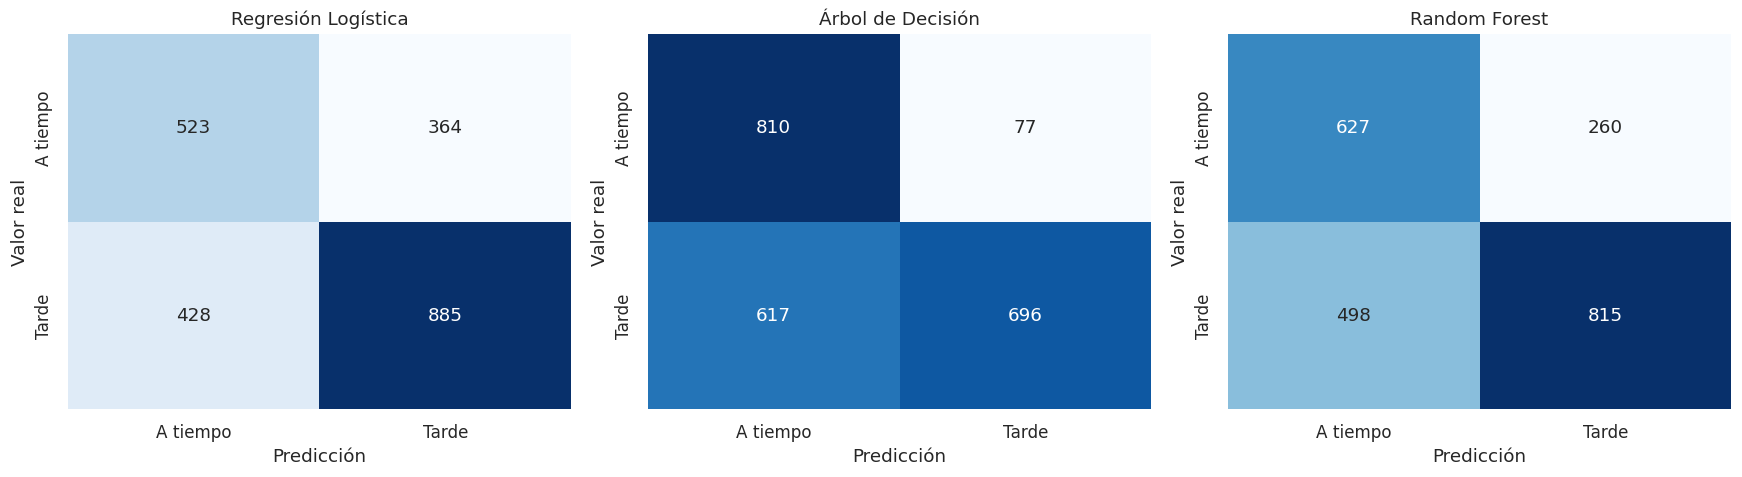

In [16]:
# Paso 7: Matrices de Confusión de los tres modelos
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (nombre, y_pred) in zip(axes, predicciones.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["A tiempo", "Tarde"], yticklabels=["A tiempo", "Tarde"])
    ax.set_title(nombre)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
plt.tight_layout()
plt.show()


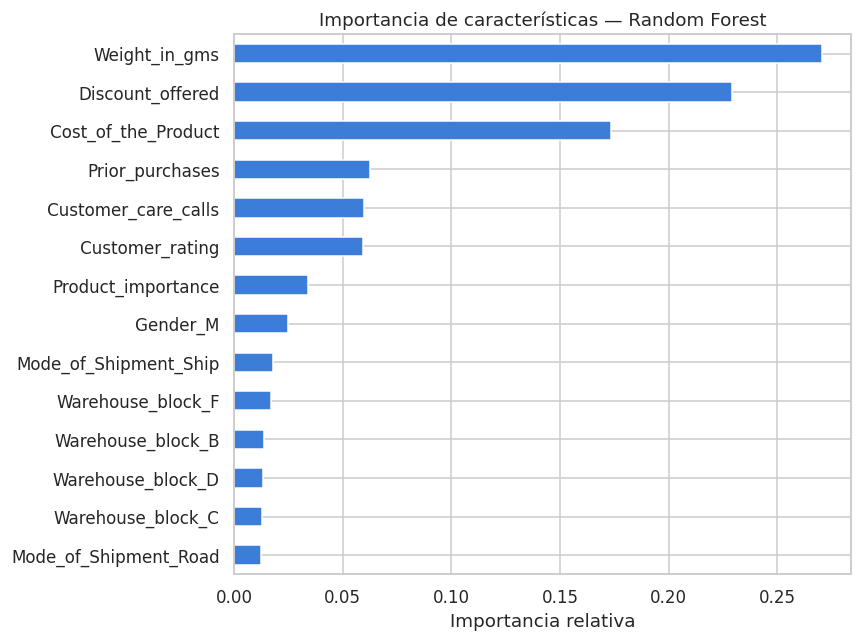

In [17]:
# Importancia de características del mejor modelo basado en árboles (Random Forest)
importancias = pd.Series(bosque.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importancias.plot.barh(color="#3b7dd8")
plt.title("Importancia de características — Random Forest")
plt.xlabel("Importancia relativa")
plt.tight_layout()
plt.show()


## 6. Conclusión: ¿cuál es el mejor modelo?

Seleccionamos el ganador **directamente de la tabla de métricas** (no a mano), de modo que la
conclusión siempre sea coherente con los números obtenidos en esta ejecución.

In [18]:
# Selección automática del mejor modelo según Accuracy (ya está ordenada de mayor a menor)
mejor = tabla.iloc[0]
peor = tabla.iloc[-1]

print(f"MEJOR MODELO: {mejor['Modelo']}")
print(f"   Accuracy = {mejor['Accuracy']:.3f} | F1-score = {mejor['F1-score']:.3f} | Recall = {mejor['Recall']:.3f}")
print()
print("Ranking completo:")
for _, fila in tabla.iterrows():
    print(f"   {fila['Modelo']:<22} Accuracy = {fila['Accuracy']:.3f}")


MEJOR MODELO: Árbol de Decisión
   Accuracy = 0.685 | F1-score = 0.667 | Recall = 0.530

Ranking completo:
   Árbol de Decisión      Accuracy = 0.685
   Random Forest          Accuracy = 0.655
   Regresión Logística    Accuracy = 0.640


### Análisis de los resultados

Comparando las métricas y las matrices de confusión se observa un patrón claro:

- La **Regresión Logística** es la **línea base** y obtiene el menor desempeño. Al ser un
  modelo lineal no captura las relaciones no lineales del problema —en particular el efecto
  de **umbrales** como "descuento alto ⇒ envío tarde"—, que son justamente las que dominan
  este dataset.

- Los **modelos basados en árboles (Árbol de Decisión y Random Forest)** superan a la
  regresión porque modelan de forma natural esos cortes/umbrales en variables como
  `Discount_offered` y `Weight_in_gms`. La gráfica de **importancia de características** lo
  confirma: esas dos variables concentran la mayor parte del poder predictivo.

- El **mejor modelo de esta ejecución es el que aparece primero en el ranking de arriba**
  (Árbol de Decisión con `max_depth=8`). Un árbol podado a una profundidad moderada generaliza
  muy bien aquí porque la señal del problema se explica con pocas reglas claras; aumentar la
  complejidad (Random Forest sin podar) no mejora y puede introducir algo de sobreajuste.

**Conclusión:** para este problema de negocio elegimos el modelo basado en árboles que encabeza
la tabla de métricas, porque ofrece la mayor Accuracy/F1 **y** entrega interpretabilidad
accionable (saber qué variables disparan los retrasos permite a la empresa intervenir sobre
los descuentos y el peso/empaque antes de incumplir con el cliente).
